In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris #Base de datos que usaremos
from sklearn.decomposition import PCA

# Análisis de componentes principales (PCA)
Convierte muchas variables correlacionadas en menos variables nuevas llamadas componentes principales, manteniendo la mayor cantidad posible de información.<br><br>

**Visualizar datos complejos**<br>
Permite representar datos con muchas dimensiones en 2D o 3D para analizarlos o encontrar patrones.<br><br>

**Eliminar redundancia y ruido**<br>
Si varias variables contienen información similar, PCA las combina, simplificando el conjunto de datos.<br><br>

**Mejorar modelos de machine learning**<br>
Con menos variables, los modelos suelen:<br>

 - Entrenar más rápido<br>

 - Evitar sobreajuste<br>

 - Manejar mejor datos muy grandes.

In [3]:
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [4]:
X = iris.data
y = iris.target

In [5]:
X #Informacion de cada flor

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [7]:
y #A que tipo de especie pertenece cada flor

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

## Estandarización de datos
Estamos restando a cada valor de X el promedio de toda la bbdd de X, para que veamos la desviación que tiene cada una<br>
Esto es importante puesto que necesitamos que todos los valores empiecen desde el mismo punto de partida y nos ayuda a ver cuales datos sobresalen<br>
Esto es como hacer que todos los participantes de una carrera empiecen desde un punto de partida para poder medir justamente

In [8]:
X_centrado = X - np.mean(X, axis = 0)

In [26]:
pca = PCA(n_components = 2) #Estamos diciendo que queremos poner 2 valores en nuestra pca, reduciendo así los datos de X a 2

In [10]:
X_pca = pca.fit_transform(X_centrado) #Entrenamos el modelo pca con nuestro X_centrado

In [23]:
especies = ["setosa", "versicolor", "virginica"] #Esto será para ponerle nombre a nuestros valores de y
colores = ["Blue","Yellow","Red"] #Esto es para que yo pueda diferenciar bien los colores

## Gráfico
Aquí lo que haremos será un bucle for por cada especie que tengamos, en este caso son 3.<br><br>
Lo que hemos puesto en los valores de X e Y del gráfico:<br>
    X - Necesitamos los datos de X_pca de la columna "0" con la misma especie. <br>
    Y - Necesitamos los datos de X_pca de la columna "1" con la misma especie. <br><br>
Luego pondremos el "label" de especies para que sea más fácil identificarlas

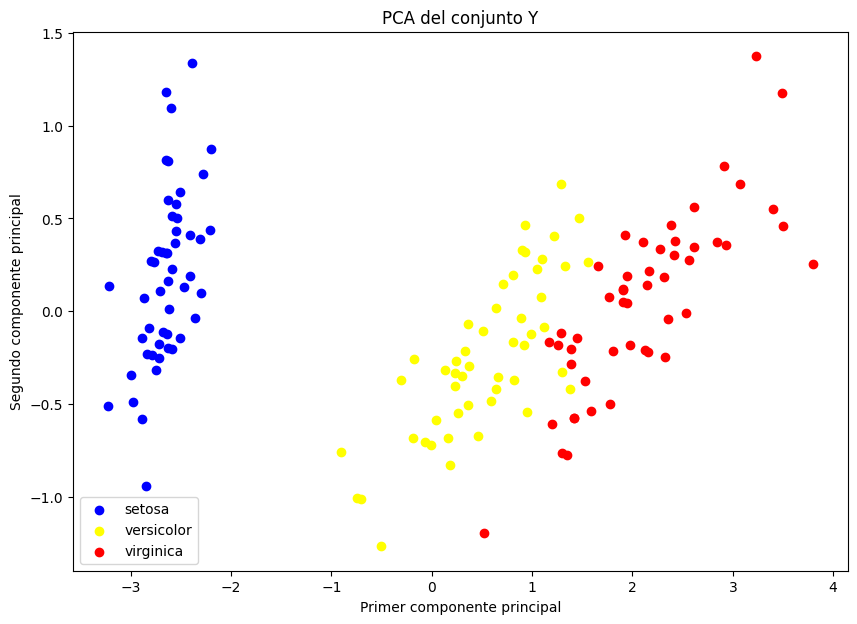

In [24]:
plt.figure(figsize = (10,7))
for i in range(0,3):
    plt.scatter(X_pca[y==i, 0], X_pca[y==i, 1], label = especies[i], c=colores[i])
plt.xlabel("Primer componente principal")
plt.ylabel("Segundo componente principal")
plt.legend()
plt.title("PCA del conjunto Y");